# Импорты

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.linalg import svd

# Для адаптивной окрестности - попарные расстояния
from scipy.spatial.distance import pdist

# Функции

In [ ]:
def center_embeddings_relative_to_center(embeddings, center_index):
    """
    Центрирует эмбеддинги относительно точки с индексом center_index.
    """
    center = embeddings[center_index]
    return embeddings - center


def find_epsilon_neighborhood(X, center_index, epsilon):
    """
    Находит все точки в эпсилон-окрестности относительно точки с индексом center_index в X.
    """
    distances = cdist(X[center_index].reshape(1, -1), X, metric="euclidean")
    distances = distances.flatten()

    in_epsilon = distances <= epsilon  # Все точки внутри эпсилон-окрестности
    all_indices = np.where(in_epsilon)[0]  # Индексы точек в окрестности

    return all_indices


def find_k_nearest_neighbors(X, center_index, k=4):
    """
    Находит k ближайших соседей относительно точки с индексом center_index в X.
    """
    distances = cdist(X[center_index].reshape(1, -1), X, metric="euclidean")
    distances = distances.flatten()
    sorted_indices = np.argsort(distances)
    return sorted_indices[1 : k + 1]


def rankme(s):
    norm_1 = np.sum(np.abs(s))
    p_k = np.abs(s) / (norm_1 + 1e-10)
    entropy = -np.sum(p_k * np.log(p_k + 1e-10))
    rankme_value = np.exp(entropy)

    return rankme_value


def compute_metric(X, Y, center_index, k=None, epsilon=None, use_softrank=True):
    """
    Вычисляет метрику сравнения пространств для заданной центральной точки.
    ИЛИ по k ближайших соседей, ИЛИ по эпсилон-окрестности.

    Args:
        X: эмбеддинги пространства A (n_samples, dim_a)
        Y: эмбеддинги пространства B (n_samples, dim_b) для ТЕХ ЖЕ объектов
        center_index: индекс центральной точки
        k: размер локальной окрестности
        epsilon: радиус окрестности
        use_softrank: если True - использовать softrank (энтропию), иначе - жесткий ранг

    Returns:
        metric_value: значение метрики
        M: найденная матрица преобразования (для анализа)
    """
    # Проверка
    if (k is None and epsilon is None) or (k is not None and epsilon is not None):
        raise ValueError("Должен быть указан ровно один из параметров: k или epsilon")

    # Для эпсилон-окрестности
    if k is None:
        neighbors_indices = find_epsilon_neighborhood(
            X, center_index, epsilon
        )  # Все точки в эпсилон-окрестности

        # Достаточно ли точек для анализа
        if len(neighbors_indices) < 3:
            return np.nan, None, None

        # Проверка присутствия центральной точки в окрестности
        if center_index not in neighbors_indices:
            return np.nan, None, None
        center_pos_in_neighbors = np.where(neighbors_indices == center_index)[0][
            0
        ]  # Позиция центральной точки

        # Центрирование относительно центральной точки
        X_centered = center_embeddings_relative_to_center(
            X[neighbors_indices], center_pos_in_neighbors
        )
        Y_centered = center_embeddings_relative_to_center(
            Y[neighbors_indices], center_pos_in_neighbors
        )

    # Для k ближайших
    else:
        neighbors_indices = find_k_nearest_neighbors(X, center_index, k)
        all_indices = np.concatenate(
            [[center_index], neighbors_indices]
        )  # Добавление центральной точки в окрестность
        center_pos_in_neighbors = 0  # Центральная точка всегда на позиции 0

        X_centered = center_embeddings_relative_to_center(
            X[all_indices], center_pos_in_neighbors
        )
        Y_centered = center_embeddings_relative_to_center(
            Y[all_indices], center_pos_in_neighbors
        )

    M = np.linalg.pinv(X_centered).dot(
        Y_centered
    )  # X_centered * M \approx Y_centered с помощью псевдообратной матрицы
    U, s, Vt = svd(M, full_matrices=False)  # Сингулярные числа матрицы M

    if use_softrank:  # RankMe
        metric_value = rankme(s)

    else:  # Жесткий ранг
        threshold = 1e-10 * np.max(s)  # Порог для определения нулевых значений
        metric_value = np.sum(s > threshold)

    return metric_value, M, s


def compute_global_metric(X, Y, n_samples=100, k=None, epsilon=None, random_seed=42):
    """
    Вычисляет глобальную метрику, усредняя по случайным точкам.

    Args:
        X: эмбеддинги пространства A
        Y: эмбеддинги пространства B
        n_samples: количество случайных точек для усреднения
        k: размер локальной окрестности (если используется k-NN)
        epsilon: радиус окрестности (если используется эпсилон-окрестность)
        random_seed: seed для воспроизводимости

    Returns:
        mean_metric: среднее значение метрики
        std_metric: стандартное отклонение
        all_values: все значения метрик
    """
    np.random.seed(random_seed)

    n = X.shape[0]
    if n_samples > n:
        n_samples = n

    random_indices = np.random.choice(
        n, size=n_samples, replace=False
    )  # Выбор случайных центральных точек

    all_values = []
    for idx in random_indices:
        metric_value, _, _ = compute_metric(
            X, Y, idx, k=k, epsilon=epsilon, use_softrank=True
        )
        if not np.isnan(metric_value):
            all_values.append(metric_value)

    return np.mean(all_values), np.std(all_values), np.array(all_values)

# Тесты на синтетике

In [ ]:
def test_comparison(X, Y):
    """
    Сравнение методов k-NN и эпсилон-окрестности.
    """
    center_index = 0

    # 1. k-NN метод
    print("=== Метод k-NN (k=10) ===")
    metric_k, M_k, s_k = compute_metric(X, Y, center_index, k=10)
    mean_k, std_k, values_k = compute_global_metric(X, Y, k=10, n_samples=500)
    print(f"Локальная метрика: {metric_k:.4f}")
    print(f"Глобальная метрика: {mean_k:.4f} ± {std_k:.4f}")

    # 2. эпсилон-метод
    print("\n=== Метод эпсилон-окрестности ===")
    X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
    Y_norm = (Y - Y.mean(axis=0)) / Y.std(axis=0)

    # Адаптивный эпсилон на основе статитики попарных расстояний и процентиля
    sample_idx = np.random.choice(X_norm.shape[0], size=500, replace=False)
    distances = pdist(X_norm[sample_idx])
    epsilon = np.percentile(distances, 10)
    print(f"Выбранный адаптивный эпсилон: {epsilon:.4f}")

    metric_eps, M_eps, s_eps = compute_metric(
        X_norm, Y_norm, center_index, epsilon=epsilon
    )
    mean_eps, std_eps, values_eps = compute_global_metric(
        X_norm, Y_norm, epsilon=epsilon, n_samples=500
    )
    print(f"Локальная метрика: {metric_eps:.4f}")
    print(f"Глобальная метрика: {mean_eps:.4f} ± {std_eps:.4f}")

    # Графики
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.hist(values_k, bins=15, alpha=0.5, edgecolor=None, label=f"k-NN: {mean_k:.3f}")
    plt.hist(
        values_eps, bins=15, alpha=0.5, edgecolor=None, label=f"эпсилон: {mean_eps:.3f}"
    )
    plt.axvline(mean_k, color="blue", linestyle="--", linewidth=1)
    plt.axvline(mean_eps, color="red", linestyle="--", linewidth=1)
    plt.xlabel("Значение метрики")
    plt.ylabel("Частота")
    plt.title("Распределение локальных метрик")
    plt.legend()

    plt.subplot(1, 2, 2)
    max_rank = min(dim_a, dim_b)
    x_positions = np.arange(1, max_rank + 1)

    plt.plot(x_positions[: len(s_k)], s_k, "bo-", label="k-NN", markersize=6)
    if s_eps is not None and len(s_eps) > 0:
        plt.plot(x_positions[: len(s_eps)], s_eps, "ro-", label="эпсилон", markersize=6)

    plt.axhline(y=0, color=None, linestyle="-", alpha=0)
    plt.xlabel("Номер сингулярного числа")
    plt.ylabel("Значение")
    plt.title("Сингулярные числа матрицы M")
    plt.legend()
    plt.grid(True, alpha=0.3, linestyle="--")

    plt.tight_layout()
    plt.show()

    # Анализ
    print(f"\n{'='*30}")
    print("АНАЛИЗ РЕЗУЛЬТАТОВ:")
    print("=" * 30)
    print(f"Максимально возможный softrank: {max_rank}")
    print(f"k-NN: {mean_k:.2f} ({mean_k/max_rank*100:.1f}%)")
    print(f"Эпсилон: {mean_eps:.2f} ({mean_eps/max_rank*100:.1f}%)")

    return {
        "knn": {
            "local": metric_k,
            "global": mean_k,
            "std": std_k,
            "values": values_k,
            "singular_values": s_k,
        },
        "epsilon": {
            "local": metric_eps,
            "global": mean_eps,
            "std": std_eps,
            "values": values_eps,
            "singular_values": s_eps,
        },
    }

=== Метод k-NN (k=10) ===
Локальная метрика: 7.0075
Глобальная метрика: 6.4413 ± 1.1934

=== Метод эпсилон-окрестности ===
Выбранный адаптивный эпсилон: 3.1496
Локальная метрика: 7.2816
Глобальная метрика: 7.2941 ± 0.0185


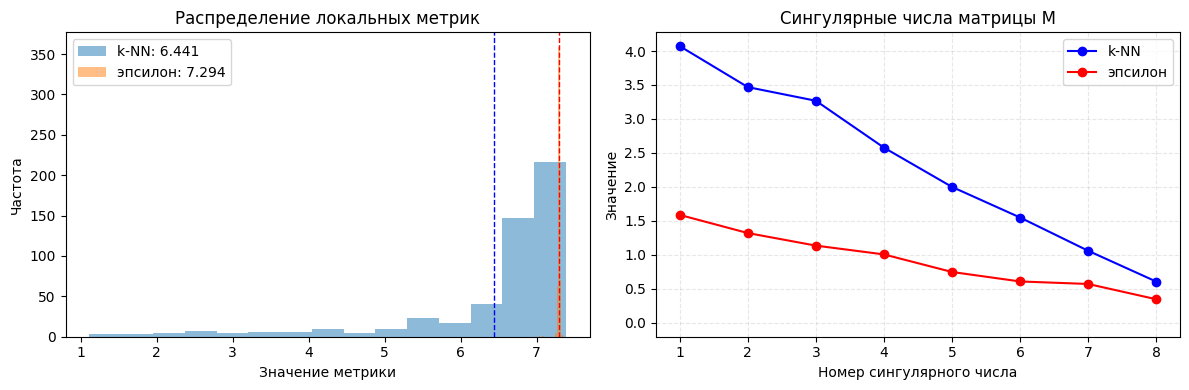


АНАЛИЗ РЕЗУЛЬТАТОВ:
Максимально возможный softrank: 8
k-NN: 6.44 (80.5%)
Эпсилон: 7.29 (91.2%)


In [ ]:
# Тестовые данные
np.random.seed(42)
n_objects = 10000
dim_a, dim_b = 10, 8

X = np.random.randn(n_objects, dim_a)
M_true = np.random.randn(dim_a, dim_b) * 0.8
Y = X.dot(M_true) + np.random.randn(n_objects, dim_b) * 0.1

# Запуск теста
results = test_comparison(X, Y)